# Import libraries and dataset

In [4]:
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
import numpy as np 
import matplotlib.pyplot as plt
import torchvision.utils

In [5]:
path_images = "data_clouds/clouds_train"

# Transform 
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [6]:
# Dataset and DataLoader
dataset = ImageFolder(root=path_images, transform=transform)

dataloader = DataLoader(dataset, batch_size =8, shuffle=True)

# Model Architecture

In [7]:
LATENT_DIM = 128

In [8]:
# Encoder Class
class Encoder(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(1, out_channels=6, kernel_size=3) # Output: batch_size, 6, 62, 62
        self.conv2 = nn.Conv2d(6, out_channels=16, kernel_size=3) # Output: batch_size, 16, 60, 60
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(16*60*60, LATENT_DIM)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

In [15]:
# Decoder Class
class Decoder(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.fc = nn.Linear(LATENT_DIM, 16*60*60)
        self.conv2 = nn.ConvTranspose2d(16, out_channels=6, kernel_size=3) # Output: batch_size, 16, 60, 60
        self.conv1 = nn.ConvTranspose2d(6, out_channels=1, kernel_size=3) # Output: batch_size, 6, 62, 62
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 16, 60, 60) # From 2D (Batch size, features) to 4D (Batch size, channels, height, width)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.conv1(x)
        x = self.relu(x)
        return x

In [16]:
# AutoEncoder class
class AutoEncoder(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [17]:
# TEST MODEL
input = torch.rand((1, 1, 64, 64)) # batch_size, channels, height, width
model = AutoEncoder()
model(input).shape

torch.Size([1, 1, 64, 64])

# TRAINING THE MODEL

In [18]:
model = AutoEncoder()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
num_epochs = 30

In [14]:
for epoch in range(num_epochs):
    losses_epoch = []
    for batch_idx, (data, target) in enumerate(dataloader):
        data = data.view(-1, 1, 64, 64)
        output = model(data)

        loss = criterion(output, data)
        losses_epoch.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {np.mean(losses_epoch)}")   

Epoch 1/30, Loss: 0.1133140784377853
Epoch 2/30, Loss: 0.07363298038641612
Epoch 3/30, Loss: 0.07237440223495166
Epoch 4/30, Loss: 0.07364101860051354
Epoch 5/30, Loss: 0.0725203157402575
Epoch 6/30, Loss: 0.07272263647367556
Epoch 7/30, Loss: 0.07243880896518627
Epoch 8/30, Loss: 0.07352952963362137
Epoch 9/30, Loss: 0.07164039251705011
Epoch 10/30, Loss: 0.07253054777781169
Epoch 11/30, Loss: 0.07137363903845349
Epoch 12/30, Loss: 0.07207852130134901
Epoch 13/30, Loss: 0.07426659117142359
Epoch 14/30, Loss: 0.07402621839816372
Epoch 15/30, Loss: 0.07390458472073078
Epoch 16/30, Loss: 0.07358849924057723
Epoch 17/30, Loss: 0.07416262924671173
Epoch 18/30, Loss: 0.07430358255902926
Epoch 19/30, Loss: 0.07502929245432217
Epoch 20/30, Loss: 0.07370141446590424
Epoch 21/30, Loss: 0.07341732556621233
Epoch 22/30, Loss: 0.07309326563651362
Epoch 23/30, Loss: 0.07461249716579914
Epoch 24/30, Loss: 0.073827399003009
Epoch 25/30, Loss: 0.07336418324460586
Epoch 26/30, Loss: 0.073634624419113
E

In [19]:
def show_image(img):
    img = 0.5 * (img+1) # denormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

original


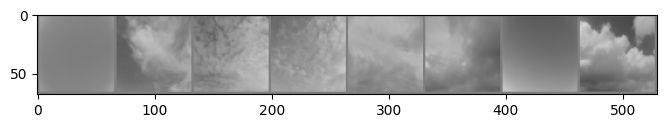

In [21]:
images, labels = next(iter(dataloader))
print('original')
plt.rcParams['figure.figsize'] = (8, 8)
show_image(torchvision.utils.make_grid(images))
plt.show()

In [22]:
print('latent space')
latent_img = model.encoder(images)
print(latent_img.shape)
print('reconstructed image')
reconstructed_img = model.decoder(latent_img)
plt.rcParams['figure.figsize'] = (8, 8)

latent space
torch.Size([8, 128])
reconstructed image
